# Bar plot: visualizing the TPM of a single gene  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import numpy as np
import matplotlib.patches as mpatches

import matplotlib as mpl
from matplotlib import font_manager

arial_path = "/media/scratch/fy2306/tools/fonts"
font_files = font_manager.findSystemFonts(fontpaths=arial_path)

for file in font_files:
    font_manager.fontManager.addfont(file)
    
mpl.rcParams['font.family'] = 'Arial'

In [2]:
rc_path = "/media/scratch/fy2306/projects/base_editing/data/ASO_rnaseq/batch_2/raw_count_matrix.txt"
df_rc = pd.read_csv(rc_path, sep="\t", names=["Geneid", "Chr", "Start", "End", "Strand", "Length", "XP047", "XP048", "XP049", "XP050", "XP051", "XP052", "XP053", "XP054", "XP055", "XP056", "XP057", "XP058"], comment="#")
print(df_rc["Length"].isna().sum())
df_rc = df_rc.drop(index=0)
df_rc.head()

0


/tmp/ipykernel_982760/206494623.py:2: DtypeWarning: Columns (5,6,7,8,9,10,11,12,13,14,15,16,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df_rc = pd.read_csv(rc_path, sep="\t", names=["Geneid", "Chr", "Start", "End", "Strand", "Length", "XP047", "XP048", "XP049", "XP050", "XP051", "XP052", "XP053", "XP054", "XP055", "XP056", "XP057", "XP058"], comment="#")


,Geneid,Chr,Start,End,Strand,Length,XP047,XP048,XP049,XP050,XP051,XP052,XP053,XP054,XP055,XP056,XP057,XP058
1,ENSG00000290825.2,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,11121;11125;11410;11411;11426;11770;11819;1182...,11211;11211;11671;11671;11671;11844;11844;1184...,+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;+;...,2898,1,0,0,0,0,1,0,0,0,0,0,0
2,ENSG00000223972.6,chr1;chr1;chr1;chr1;chr1;chr1,12010;12179;12613;12975;13221;13453,12057;12227;12697;13052;13374;13670,+;+;+;+;+;+,632,0,0,0,0,0,0,0,0,0,0,0,0
3,ENSG00000310526.1,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;c...,14356;14356;14356;14356;14356;14356;14356;1436...,14829;14829;14829;14829;14829;14829;14829;1482...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;...,6775,27,10,11,21,22,16,13,15,4,13,20,24
4,ENSG00000227232.6,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,14696;14970;15796;16607;16858;17233;17606;1791...,14829;15038;15947;16765;17055;17368;17742;1806...,-;-;-;-;-;-;-;-;-;-,1380,0,0,0,0,0,0,0,0,0,0,0,0
5,ENSG00000278267.1,chr1,17369,17436,-,68,0,0,0,0,0,0,0,0,0,0,0,0


In [3]:
# TPM
sample_cols = [col for col in df_rc.columns if col.startswith("XP0")]
for col in sample_cols:
    df_rc[col] = pd.to_numeric(df_rc[col], errors="coerce")

df_rc["Length"] = pd.to_numeric(df_rc["Length"], errors="coerce")
df_rc = df_rc.dropna(subset=["Length"])
df_rpk = df_rc[sample_cols].div(df_rc["Length"] / 1000, axis=0)
rpk_sums = df_rpk.sum(axis=0)
print(rpk_sums)
df_tpm = df_rpk.div(rpk_sums, axis=1) * 1e6
df_tpm = pd.concat([df_rc[["Geneid", "Chr", "Start", "End", "Strand", "Length"]], df_tpm], axis=1)
print(df_tpm["Geneid"])
mapping_path = "/media/dna/fy2306/genomes/hg38/GENCODE/gencode.v47.annotation.gene_id2gene_name.tsv"
mapping = pd.read_csv(mapping_path, sep="\t", header=None, names=["Geneid", "gene_name"])
df_tpm = df_tpm.merge(mapping, on="Geneid", how="left")
df_tpm["Geneid"] = df_tpm["gene_name"]
df_tpm["Geneid"]

XP047    6.216499e+06
XP048    5.615437e+06
XP049    5.355749e+06
XP050    6.494188e+06
XP051    6.098868e+06
XP052    6.667837e+06
XP053    6.164049e+06
XP054    5.221916e+06
XP055    5.706950e+06
XP056    5.213616e+06
XP057    6.300075e+06
XP058    5.933720e+06
dtype: float64
1        ENSG00000290825.2
2        ENSG00000223972.6
3        ENSG00000310526.1
4        ENSG00000227232.6
5        ENSG00000278267.1
               ...        
78720    ENSG00000198695.2
78721    ENSG00000210194.1
78722    ENSG00000198727.2
78723    ENSG00000210195.2
78724    ENSG00000210196.2
Name: Geneid, Length: 78724, dtype: object


0         DDX11L16
1          DDX11L1
2           WASH7P
3           WASH7P
4        MIR6859-1
           ...    
78719       MT-ND6
78720        MT-TE
78721       MT-CYB
78722        MT-TT
78723        MT-TP
Name: Geneid, Length: 78724, dtype: object

In [4]:
groups = {
    "Control_48":   ["XP047", "XP048", "XP049"],
    "Treatment_48": ["XP050", "XP051", "XP052"],
    "Control_72":   ["XP053", "XP054", "XP055"],
    "Treatment_72": ["XP056", "XP057", "XP058"],
}

In [5]:
def plot_gene_tpm(df_tpm, gene, groups, error="sd", bar_width=0.3, pair_gap=1.2, jitter=0.06, seed=7):

	sel = df_tpm["Geneid"] == gene
	row = df_tpm.loc[sel].iloc[0]

	clean = {}
	for k, cols in groups.items():
		present = [c for c in cols if c in df_tpm.columns]
		missing = sorted(set(cols) - set(present))
		if missing:
			print(f"[warning] {k}: missing columns ignored: {missing}")
		vals = row[present].astype(float).to_numpy()
		vals = vals[~np.isnan(vals)]
		clean[k] = vals

	def mean_err(a):
		if a.size == 0:
			return np.nan, np.nan
		m = float(np.mean(a))
		if error == "sem":
			e = (np.std(a, ddof=1) / np.sqrt(a.size)) if a.size > 1 else np.nan
		elif error == "sd":
			e = np.std(a, ddof=1) if a.size > 1 else 0.0
		else:
			raise ValueError("error must be 'sd' or 'sem'")
		return m, float(e)

	m48_c, e48_c = mean_err(clean["Control_48"])
	m48_t, e48_t = mean_err(clean["Treatment_48"])
	m72_c, e72_c = mean_err(clean["Control_72"])
	m72_t, e72_t = mean_err(clean["Treatment_72"])

	print(f"LFC 48h: {np.log2((m48_t) / (m48_c)):.3f}, LFC 72h: {np.log2((m72_t) / (m72_c)):.3f}")

	# # p-values (Welch t-test)
	# def welch(a, b):
	# 	if a.size < 2 or b.size < 2:
	# 		return np.nan
	# 	if np.all(a == a[0]) and np.all(b == b[0]) and a[0] == b[0]:
	# 		return 1.0
	# 	_, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
	# 	return float(p)

	# # p-values (Mann-Whitney U test)
	# def mannwhitney(a, b):
	# 	_, p = stats.mannwhitneyu(a, b, alternative="two-sided")
	# 	return float(p)
	
	# # p-values (Welch t-test on log-transformed)
	# def welch_log(a, b, pseudocount=1.0):
	# 	a = np.log2(a + pseudocount)
	# 	b = np.log2(b + pseudocount)
	# 	_, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
	# 	return float(p)

	# p48 = welch_log(clean["Control_48"], clean["Treatment_48"])
	# p72 = welch_log(clean["Control_72"], clean["Treatment_72"])

	def p_to_stars(p):
		if np.isnan(p): return "n/a"
		if p < 1e-3: return "***"
		if p < 1e-2: return "**"
		if p < 5e-2: return "*"
		return "ns"

	offset = bar_width / 2
	x_positions = {
		"Control_48":   -offset,
		"Treatment_48": +offset,
		"Control_72":   pair_gap - offset,
		"Treatment_72": pair_gap + offset,
	}

	colors = {
		"Control_48":   "#66CCFE",
		"Treatment_48": "#FF0066",
		"Control_72":   "#66CCFE",
		"Treatment_72": "#FF0066",
	}

	means = {
		"Control_48": m48_c, "Treatment_48": m48_t,
		"Control_72": m72_c, "Treatment_72": m72_t
	}
	errs = {
		"Control_48": e48_c, "Treatment_48": e48_t,
		"Control_72": e72_c, "Treatment_72": e72_t
	}

	rng = np.random.default_rng(seed)
	fig, ax = plt.subplots(figsize=(4, 4.5))

	for k in ["Control_48", "Treatment_48", "Control_72", "Treatment_72"]:
		x = x_positions[k]
		m, e = means[k], errs[k]
		ax.bar(x, m, width=bar_width, color=colors[k], edgecolor="black",
				yerr=e if np.isfinite(e) else None, capsize=6, linewidth=1.2, zorder=2)

		vals = clean[k]
		if vals.size:
			xj = x + rng.uniform(-jitter, jitter, size=vals.size)
			ax.scatter(xj, vals, s=36, c="black", alpha=0.9, zorder=3)

	def sig_between(ax, x1, x2, y, label, pad=0.03):
		ax.plot([x1, x2], [y, y], color="black", linewidth=1.2)
		ax.text((x1 + x2) / 2, y + pad * y, label, ha="center", va="bottom", fontsize=14)

	def group_top(keys):
		vals = []
		for k in keys:
			m, e = means[k], errs[k]
			arr = [m + (e if np.isfinite(e) else 0.0)]
			arr.extend(clean[k] if clean[k].size else [])
			vals.append(np.nanmax(arr) if len(arr) else 0.0)
		t = np.nanmax(vals) if len(vals) else 0.0
		return 1.0 if not np.isfinite(t) or t <= 0 else t

	top_48 = group_top(["Control_48", "Treatment_48"])
	top_72 = group_top(["Control_72", "Treatment_72"])

	y48 = top_48 * 1.08
	y72 = top_72 * 1.08
	# sig_between(ax, x_positions["Control_48"], x_positions["Treatment_48"], y48, p_to_stars(p48))
	# sig_between(ax, x_positions["Control_72"], x_positions["Treatment_72"], y72, p_to_stars(p72))
	# print(p48, p72)

	ax.set_xticks([0.0, pair_gap])
	ax.set_xticklabels(["48 h", "72 h"])

	ax.set_ylabel("TPM", fontsize=14)
	ax.set_title(gene, fontsize=14)
	ax.grid(axis="y", linestyle=":", alpha=0.5, zorder=0)

	ymax_all = np.nanmax([y48, y72])
	if not np.isfinite(ymax_all) or ymax_all <= 0:
		ymax_all = 1.0
	ax.set_ylim(0, ymax_all * 1.35)

	ctrl_patch = mpatches.Patch(color="#66CCFE", label="Control")
	treat_patch = mpatches.Patch(color="#FF0066", label="Treatment")
	ax.legend(handles=[ctrl_patch, treat_patch], frameon=False, loc="upper right", fontsize=14)

	ax.spines["top"].set_visible(False)
	ax.spines["right"].set_visible(False)

	ax.tick_params(axis="x", labelsize=14)
	ax.tick_params(axis="y", labelsize=13)
	plt.grid(False)
	fig.tight_layout()
	plt.savefig(f"/media/scratch/fy2306/projects/base_editing/plots/ASO/tpm_barplot.{gene}.pdf", 
				bbox_inches="tight",
				dpi=300,              
				transparent=True,
				format='pdf')
	return fig, ax

LFC 48h: -0.027, LFC 72h: 0.022
LFC 48h: 0.739, LFC 72h: 0.616
LFC 48h: 0.128, LFC 72h: 0.477
LFC 48h: 0.499, LFC 72h: 0.268
LFC 48h: -0.099, LFC 72h: -0.015
LFC 48h: 0.685, LFC 72h: 0.920


(<Figure size 400x450 with 1 Axes>,
 <Axes: title={'center': 'USP38-DT'}, ylabel='TPM'>)

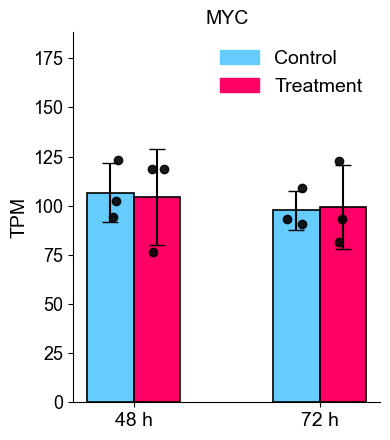

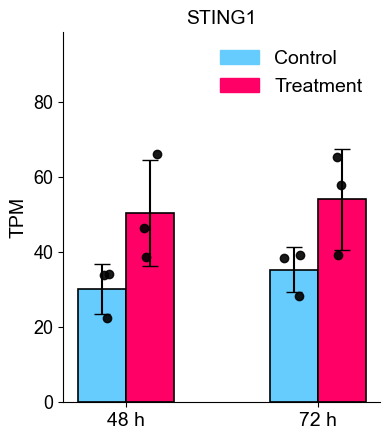

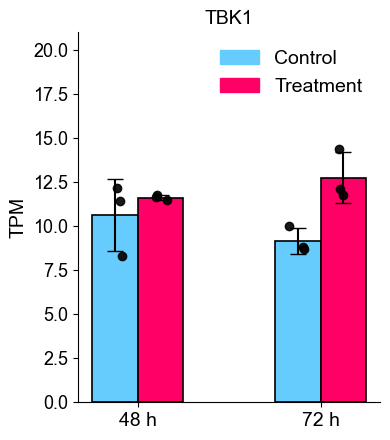

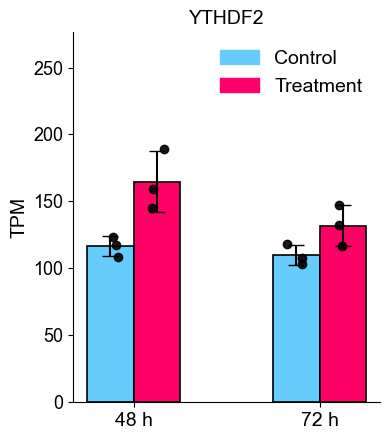

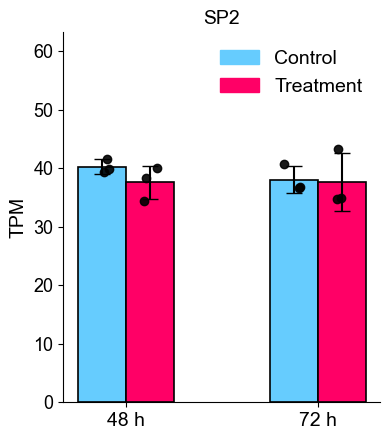

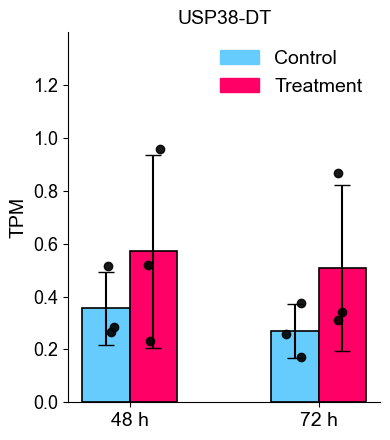

In [7]:
plot_gene_tpm(df_tpm, gene="MYC", groups=groups, error="sd")
# plot_gene_tpm(df_tpm, gene="SP2", groups=groups, error="sd")
# plot_gene_tpm(df_tpm, gene="SLC5A6", groups=groups, error="sd")
# plot_gene_tpm(df_tpm, gene="MYCL", groups=groups, error="sd")
plot_gene_tpm(df_tpm, gene="STING1", groups=groups, error="sd")
plot_gene_tpm(df_tpm, gene="TBK1", groups=groups, error="sd")
plot_gene_tpm(df_tpm, gene="YTHDF2", groups=groups, error="sd")
plot_gene_tpm(df_tpm, gene="SP2", groups=groups, error="sd")
plot_gene_tpm(df_tpm, gene="USP38-DT", groups=groups, error="sd")